In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('checkout_revenue_dataset.csv')
df.head()

,transaction_id,date,period,region,channel,customer_segment,product_category,order_completed,revenue
0,7871,2026-05-04,pre_launch,North,Web,New Customer,Grocery,0,0.00
1,1332,2026-05-04,pre_launch,North,Web,New Customer,Grocery,1,855.43
2,9931,2026-05-04,pre_launch,South,Web,Returning Customer,Electronics,1,4638.11
3,2237,2026-05-04,pre_launch,East,Android App,Returning Customer,Grocery,1,656.27
4,5572,2026-05-04,pre_launch,West,iOS App,Returning Customer,Grocery,1,635.70


In [2]:
#Detect the Anomaly — turning "there's an 18% drop" from a claim into an actual, visible, calculated fact.

In [3]:
daily_revenue = df.groupby('date')['revenue'].sum().reset_index()
daily_revenue.head()

,date,revenue
0,2026-05-04,696626.53
1,2026-05-05,635968.21
2,2026-05-06,677881.94
3,2026-05-07,754362.34
4,2026-05-08,710639.96


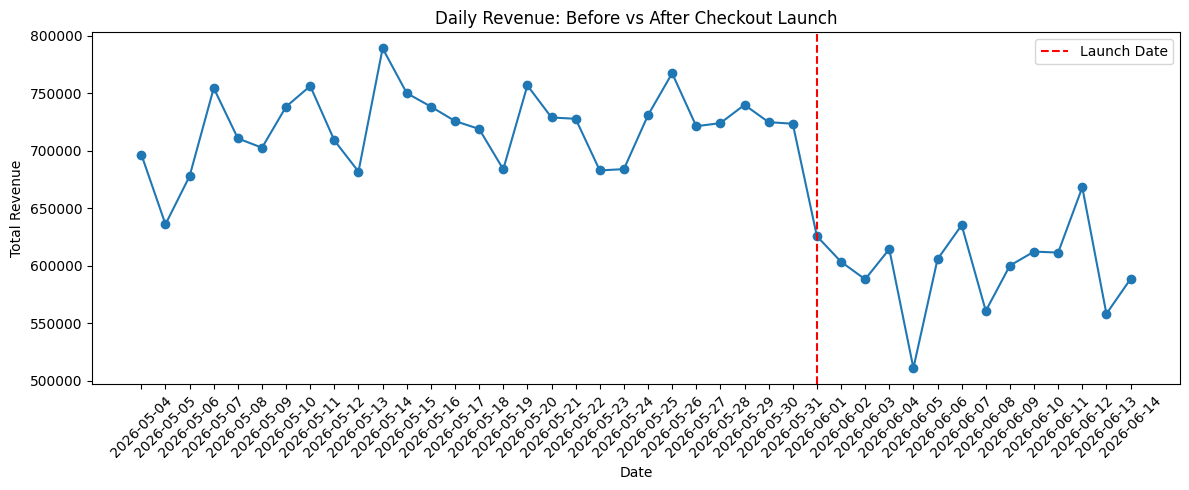

In [4]:
#turning daily revenue into chart to detect drop.
plt.figure(figsize=(12, 5))
plt.plot(daily_revenue['date'], daily_revenue['revenue'], marker='o')
plt.axvline(x='2026-06-01', color='red', linestyle='--', label='Launch Date')
plt.title('Daily Revenue: Before vs After Checkout Launch')
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
#KPI Monitoring Layer

In [6]:
def compute_daily_kpis(df):
    """
    Rolls up raw transaction-level data into a daily KPI monitoring table.

    Expects columns: date, transaction_id, order_completed, revenue
    Returns one row per date with core business KPIs:
      - conversion_rate: completed orders / total transactions (sessions)
      - aov: average order value, based on COMPLETED orders only
      - revenue_per_visitor: total revenue / total transactions (captures both effects)
    """
    daily = df.groupby('date').agg(
        total_transactions=('transaction_id', 'count'),
        completed_orders=('order_completed', 'sum'),
        total_revenue=('revenue', 'sum')
    ).reset_index()

    daily['conversion_rate'] = daily['completed_orders'] / daily['total_transactions']
    daily['aov'] = daily['total_revenue'] / daily['completed_orders']
    daily['revenue_per_visitor'] = daily['total_revenue'] / daily['total_transactions']

    return daily.sort_values('date').reset_index(drop=True)

daily_kpis = compute_daily_kpis(df)
daily_kpis

,date,total_transactions,completed_orders,total_revenue,conversion_rate,aov,revenue_per_visitor
0,2026-05-04,477,374,696626.53,0.784067,1862.637781,1460.432977
1,2026-05-05,429,338,635968.21,0.787879,1881.562751,1482.443380
2,2026-05-06,471,361,677881.94,0.766454,1877.789307,1439.239788
3,2026-05-07,492,397,754362.34,0.806911,1900.157028,1533.256789
4,2026-05-08,476,379,710639.96,0.796218,1875.039472,1492.941092
5,2026-05-09,450,363,702541.66,0.806667,1935.376474,1561.203689
6,2026-05-10,489,387,738222.42,0.791411,1907.551473,1509.657301
7,2026-05-11,503,396,756168.85,0.787276,1909.517298,1503.317793
8,2026-05-12,496,379,708834.87,0.764113,1870.276702,1429.102560
9,2026-05-13,494,377,681800.20,0.763158,1808.488594,1380.162348


In [7]:
# Compare pre vs post launch at the KPI level (not just revenue)
LAUNCH_DATE = '2026-06-01'

daily_kpis['period'] = daily_kpis['date'].apply(
    lambda d: 'pre_launch' if d < LAUNCH_DATE else 'post_launch'
)

kpi_summary = daily_kpis.groupby('period')[['conversion_rate', 'aov', 'revenue_per_visitor']].mean()
kpi_summary

,conversion_rate,aov,revenue_per_visitor
period,,,
post_launch,0.641370,1961.912897,1257.530902
pre_launch,0.793539,1908.210697,1514.431802


In [8]:
# Quantify the drop in each KPI
def pct_change(before, after):
    return (after - before) / before * 100

conv_change = pct_change(kpi_summary.loc['pre_launch', 'conversion_rate'],
                          kpi_summary.loc['post_launch', 'conversion_rate'])
aov_change = pct_change(kpi_summary.loc['pre_launch', 'aov'],
                         kpi_summary.loc['post_launch', 'aov'])
rpv_change = pct_change(kpi_summary.loc['pre_launch', 'revenue_per_visitor'],
                         kpi_summary.loc['post_launch', 'revenue_per_visitor'])

print(f"Conversion rate change:      {conv_change:+.1f}%")
print(f"AOV change:                  {aov_change:+.1f}%")
print(f"Revenue-per-visitor change:  {rpv_change:+.1f}%")

Conversion rate change:      -19.2%
AOV change:                  +2.8%
Revenue-per-visitor change:  -17.0%


In [9]:
#Step 3: Automated Anomaly Detection

In [10]:
import numpy as np

def detect_anomalies(daily_kpis, metric='conversion_rate', baseline_period='pre_launch',
                      period_col='period', z_threshold=3):
    """
    Flags anomalous days in a KPI time series using a z-score control-chart method.

    - Computes mean/std of `metric` using ONLY the baseline_period (e.g. pre-launch),
      so the "normal range" isn't contaminated by the anomaly itself.
    - Any day (in the full dataset) whose z-score exceeds z_threshold is flagged.

    Returns the input dataframe with 'z_score' and 'is_anomaly' columns added.
    """
    baseline = daily_kpis.loc[daily_kpis[period_col] == baseline_period, metric]
    mu, sigma = baseline.mean(), baseline.std()

    result = daily_kpis.copy()
    result['z_score'] = (result[metric] - mu) / sigma
    result['is_anomaly'] = result['z_score'].abs() > z_threshold

    return result, mu, sigma

daily_kpis_flagged, baseline_mean, baseline_std = detect_anomalies(daily_kpis, metric='conversion_rate')
daily_kpis_flagged[['date', 'period', 'conversion_rate', 'z_score', 'is_anomaly']]

,date,period,conversion_rate,z_score,is_anomaly
0,2026-05-04,pre_launch,0.784067,-0.510469,False
1,2026-05-05,pre_launch,0.787879,-0.305039,False
2,2026-05-06,pre_launch,0.766454,-1.459697,False
3,2026-05-07,pre_launch,0.806911,0.720668,False
4,2026-05-08,pre_launch,0.796218,0.144424,False
5,2026-05-09,pre_launch,0.806667,0.707523,False
6,2026-05-10,pre_launch,0.791411,-0.114670,False
7,2026-05-11,pre_launch,0.787276,-0.337508,False
8,2026-05-12,pre_launch,0.764113,-1.585888,False
9,2026-05-13,pre_launch,0.763158,-1.637358,False


In [11]:
print(f"Pre-launch baseline conversion rate: {baseline_mean:.2%}  (std: {baseline_std:.4f})")
print(f"Anomalous days flagged: {daily_kpis_flagged['is_anomaly'].sum()} out of {len(daily_kpis_flagged)} total days")
print(f"Post-launch days flagged as anomalies: {daily_kpis_flagged[daily_kpis_flagged.period=='post_launch']['is_anomaly'].sum()} out of {(daily_kpis_flagged.period=='post_launch').sum()}")

Pre-launch baseline conversion rate: 79.35%  (std: 0.0186)
Anomalous days flagged: 14 out of 42 total days
Post-launch days flagged as anomalies: 14 out of 14


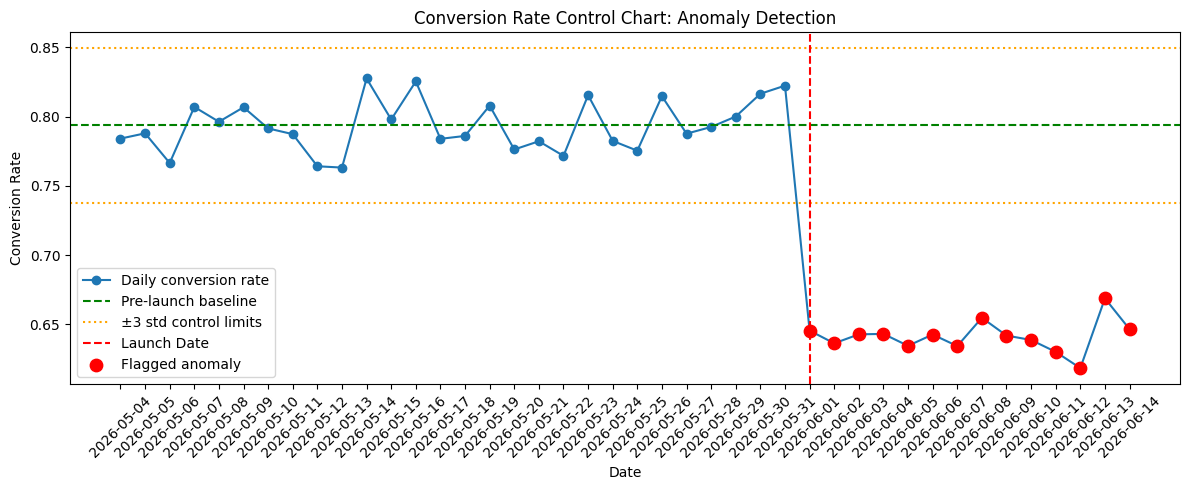

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(daily_kpis_flagged['date'], daily_kpis_flagged['conversion_rate'], marker='o', label='Daily conversion rate')
plt.axhline(y=baseline_mean, color='green', linestyle='--', label='Pre-launch baseline')
plt.axhline(y=baseline_mean - 3*baseline_std, color='orange', linestyle=':', label='±3 std control limits')
plt.axhline(y=baseline_mean + 3*baseline_std, color='orange', linestyle=':')
plt.axvline(x='2026-06-01', color='red', linestyle='--', label='Launch Date')

anomalies = daily_kpis_flagged[daily_kpis_flagged['is_anomaly']]
plt.scatter(anomalies['date'], anomalies['conversion_rate'], color='red', s=80, zorder=5, label='Flagged anomaly')

plt.title('Conversion Rate Control Chart: Anomaly Detection')
plt.xlabel('Date')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
#Step 4: Automated Root Cause Analysis (RCA)

In [14]:
def rca_by_segment(df, segment_col, period_col='period', launch_date=LAUNCH_DATE):
    """
    Breaks down conversion rate and revenue by a given segment column (e.g. 'channel',
    'region'), comparing pre vs post launch, to find which segments are driving the drop.

    Returns a table ranked by conv_pct_change (most negative = worst hit first), with:
      - conversion_rate_pre_launch / post_launch
      - conv_pct_change: relative % change in conversion rate (severity of the problem)
      - revenue_impact_per_day: absolute $ change in daily revenue (business priority)
    """
    grp = df.groupby([segment_col, period_col]).agg(
        transactions=('transaction_id', 'count'),
        completed=('order_completed', 'sum'),
        revenue=('revenue', 'sum')
    ).reset_index()
    grp['conversion_rate'] = grp['completed'] / grp['transactions']

    pivot = grp.pivot(index=segment_col, columns=period_col, values=['conversion_rate', 'revenue', 'transactions'])
    pivot.columns = ['_'.join(c) for c in pivot.columns]

    pivot['conv_pct_change'] = (
        (pivot['conversion_rate_post_launch'] - pivot['conversion_rate_pre_launch'])
        / pivot['conversion_rate_pre_launch'] * 100
    )

    n_pre_days = df[df[period_col] == 'pre_launch']['date'].nunique()
    n_post_days = df[df[period_col] == 'post_launch']['date'].nunique()
    pivot['revenue_impact_per_day'] = (
        pivot['revenue_post_launch'] / n_post_days - pivot['revenue_pre_launch'] / n_pre_days
    )

    cols = ['conversion_rate_pre_launch', 'conversion_rate_post_launch', 'conv_pct_change', 'revenue_impact_per_day']
    return pivot[cols].sort_values('conv_pct_change').round(4)

# Run RCA across every available dimension
segment_columns = ['region', 'channel', 'customer_segment', 'product_category']
rca_results = {col: rca_by_segment(df, col) for col in segment_columns}

for col, result in rca_results.items():
    print(f"--- RCA by {col} ---")
    print(result)
    print()

--- RCA by region ---
        conversion_rate_pre_launch  conversion_rate_post_launch  \
region                                                            
West                        0.8063                       0.6408   
North                       0.7892                       0.6349   
East                        0.7994                       0.6492   
South                       0.7814                       0.6407   

        conv_pct_change  revenue_impact_per_day  
region                                           
West           -20.5294             -29935.4939  
North          -19.5482             -44994.7404  
East           -18.7959             -25988.4979  
South          -17.9979             -20995.7582  

--- RCA by channel ---
             conversion_rate_pre_launch  conversion_rate_post_launch  \
channel                                                                
iOS App                          0.8041                       0.1120   
Web                              0.

In [15]:
# Rank all segments across all dimensions together, worst-hit first
combined = []
for col, result in rca_results.items():
    temp = result.copy()
    temp['dimension'] = col
    temp['segment_value'] = temp.index
    combined.append(temp)

combined_rca = pd.concat(combined).reset_index(drop=True)
combined_rca = combined_rca.sort_values('conv_pct_change')

combined_rca[['dimension', 'segment_value', 'conversion_rate_pre_launch',
              'conversion_rate_post_launch', 'conv_pct_change', 'revenue_impact_per_day']]

,dimension,segment_value,conversion_rate_pre_launch,conversion_rate_post_launch,conv_pct_change,revenue_impact_per_day
4,channel,iOS App,0.8041,0.1120,-86.0677,-136012.3943
9,product_category,Beauty,0.7922,0.6107,-22.9137,-16158.6957
10,product_category,Home,0.7954,0.6137,-22.8448,-22523.1039
0,region,West,0.8063,0.6408,-20.5294,-29935.4939
7,customer_segment,Returning Customer,0.7918,0.6365,-19.6128,-68539.4389
1,region,North,0.7892,0.6349,-19.5482,-44994.7404
2,region,East,0.7994,0.6492,-18.7959,-25988.4979
8,customer_segment,New Customer,0.7955,0.6484,-18.4951,-53375.0514
11,product_category,Fashion,0.8044,0.6566,-18.3798,-26501.4843
3,region,South,0.7814,0.6407,-17.9979,-20995.7582


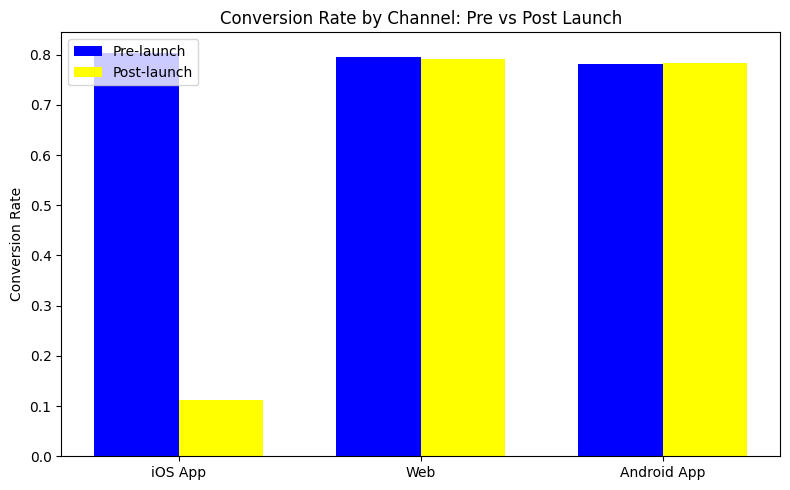

In [21]:
import matplotlib.pyplot as plt

channel_rca = rca_results['channel']

fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(channel_rca))
width = 0.35
ax.bar([i - width/2 for i in x], channel_rca['conversion_rate_pre_launch'], width, label='Pre-launch', color='blue')
ax.bar([i + width/2 for i in x], channel_rca['conversion_rate_post_launch'], width, label='Post-launch', color='yellow')
ax.set_xticks(list(x))
ax.set_xticklabels(channel_rca.index)
ax.set_ylabel('Conversion Rate')
ax.set_title('Conversion Rate by Channel: Pre vs Post Launch')
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
# Step 5: A/B Test Design (Recommend a Fix)

In [18]:
from scipy.stats import norm
import math

def sample_size_two_proportions(p1, p2, alpha=0.05, power=0.8):
    """
    Computes required sample size PER GROUP for a two-proportion A/B test.

    p1: baseline conversion rate (control)
    p2: expected conversion rate under the fix (treatment) -- the effect we want to detect
    alpha: significance level (probability of a false positive), default 5%
    power: probability of detecting a true effect if it exists, default 80%
    """
    z_alpha = norm.ppf(1 - alpha / 2)   # two-tailed critical z-value for alpha
    z_beta = norm.ppf(power)            # z-value corresponding to desired power
    pooled_var = p1 * (1 - p1) + p2 * (1 - p2)
    n = ((z_alpha + z_beta) ** 2 * pooled_var) / (p2 - p1) ** 2
    return math.ceil(n)

# Scenario 1: assume the fix fully restores conversion to the pre-launch baseline
n_optimistic = sample_size_two_proportions(p1=0.112, p2=0.804)

# Scenario 2 (conservative, recommended): assume the fix only partially works,
# and we want to reliably detect even a modest +10 percentage point improvement
n_conservative = sample_size_two_proportions(p1=0.112, p2=0.212)

print(f"Sample size per group (assuming full recovery to 80%):  {n_optimistic}")
print(f"Sample size per group (conservative, detect +10pp lift): {n_conservative}")

Sample size per group (assuming full recovery to 80%):  5
Sample size per group (conservative, detect +10pp lift): 210


In [19]:
# How long would the test need to run, given actual iOS traffic volume?
ios_daily_transactions = df[df['channel'] == 'iOS App'].groupby('date').size().mean()
print(f"Average daily iOS transactions: {ios_daily_transactions:.0f}")

# Conservative scenario needs n_conservative users in EACH of 2 groups
total_needed = n_conservative * 2
days_needed = total_needed / ios_daily_transactions
print(f"Days needed (conservative, 50/50 split): {days_needed:.1f} days")
print()
print("Recommended test duration: 14 days")
print("Rationale: statistically we could conclude sooner, but running a full 2 weeks")
print("covers weekday/weekend behavior cycles and avoids reacting to short-term novelty effects.")

Average daily iOS transactions: 105
Days needed (conservative, 50/50 split): 4.0 days

Recommended test duration: 14 days
Rationale: statistically we could conclude sooner, but running a full 2 weeks
covers weekday/weekend behavior cycles and avoids reacting to short-term novelty effects.


In [ ]:
# Step 6: A/B Test Statistical Analysis

In [22]:
import numpy as np
from scipy import stats

np.random.seed(42)  # for reproducibility

n_control = n_conservative     # from Step 5 sample size calculation
n_treatment = n_conservative

control_conversion_rate = 0.112    # current broken iOS checkout
treatment_conversion_rate = 0.65   # assumed effect of the fix (conservative vs full 80% recovery)

# Simulate individual user outcomes: each user converts (1) or doesn't (0)
control_conversions = np.random.binomial(1, control_conversion_rate, n_control)
treatment_conversions = np.random.binomial(1, treatment_conversion_rate, n_treatment)

control_rate = control_conversions.mean()
treatment_rate = treatment_conversions.mean()

print(f"Control group observed conversion rate:   {control_rate:.2%}  (n={n_control})")
print(f"Treatment group observed conversion rate: {treatment_rate:.2%}  (n={n_treatment})")

Control group observed conversion rate:   11.90%  (n=210)
Treatment group observed conversion rate: 63.33%  (n=210)


In [23]:
def two_proportion_z_test(conversions_a, conversions_b):
    """
    Runs a two-proportion z-test comparing two independent groups of binary outcomes.
    Returns the z-statistic, two-tailed p-value, and 95% confidence interval for the
    difference in proportions (rate_b - rate_a).
    """
    n_a, n_b = len(conversions_a), len(conversions_b)
    rate_a, rate_b = conversions_a.mean(), conversions_b.mean()

    # Pooled proportion, used for the z-statistic under the null hypothesis (no difference)
    pooled_rate = (conversions_a.sum() + conversions_b.sum()) / (n_a + n_b)
    se_pooled = np.sqrt(pooled_rate * (1 - pooled_rate) * (1/n_a + 1/n_b))
    z_stat = (rate_b - rate_a) / se_pooled
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))  # two-tailed

    # Confidence interval uses the UNPOOLED standard error (standard practice for CIs)
    diff = rate_b - rate_a
    se_diff = np.sqrt(rate_a*(1-rate_a)/n_a + rate_b*(1-rate_b)/n_b)
    ci_low = diff - 1.96 * se_diff
    ci_high = diff + 1.96 * se_diff

    return z_stat, p_value, diff, (ci_low, ci_high)

z_stat, p_value, diff, ci = two_proportion_z_test(control_conversions, treatment_conversions)

print(f"Difference in conversion rate (treatment - control): {diff:+.2%}")
print(f"95% Confidence interval: [{ci[0]:.2%}, {ci[1]:.2%}]")
print(f"z-statistic: {z_stat:.2f}")
print(f"p-value: {p_value:.6f}")
print()
alpha = 0.05
if p_value < alpha:
    print(f"RESULT: Statistically significant (p < {alpha}). Reject the null hypothesis.")
    print("The fix produces a real improvement in iOS conversion rate -- recommend rollout.")
else:
    print(f"RESULT: Not statistically significant (p >= {alpha}). Fail to reject the null hypothesis.")
    print("Insufficient evidence the fix improves conversion -- do not roll out yet.")

Difference in conversion rate (treatment - control): +51.43%
95% Confidence interval: [43.58%, 59.28%]
z-statistic: 10.88
p-value: 0.000000

RESULT: Statistically significant (p < 0.05). Reject the null hypothesis.
The fix produces a real improvement in iOS conversion rate -- recommend rollout.


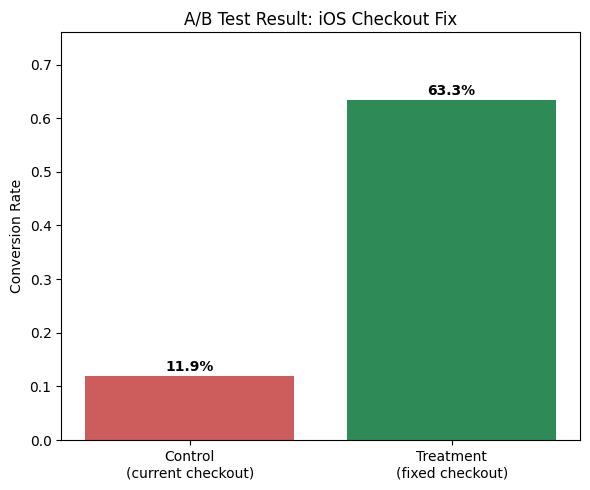

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
groups = ['Control\n(current checkout)', 'Treatment\n(fixed checkout)']
rates = [control_rate, treatment_rate]
colors = ['indianred', 'seagreen']

bars = ax.bar(groups, rates, color=colors)
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, rate + 0.01, f'{rate:.1%}', ha='center', fontweight='bold')

ax.set_ylabel('Conversion Rate')
ax.set_title('A/B Test Result: iOS Checkout Fix')
ax.set_ylim(0, max(rates) * 1.2)
plt.tight_layout()
plt.show()